# Procesado inicial de los datos de partida (2024-08-23)

In [1]:
# Se han entregado dos ficheros
## -rw-rw-r-- 1 jordieres jordieres 27999504 Jul 29 07:59 'Pacientes Trombofilia_Volcado Dr. Demelo (26-07-2024).sav'
## -rw-rw-r-- 1 jordieres jordieres 12801511 Jul 29 08:26 'Tratamientos Trombofilia_Volcado Dr. Demelo (26-07-2024).sav'


# Objetivo 1 => Perfil de Paciente con TROMBOFILIA POSITIVA => variable "ana_dura" [No buscada, Buscada Positivo, Buscada Negativo.
# (factores de riesto, edad, sexo, tipo de cancer en su caso, etc.)
# Clasificación:
#    * Por localización: Usuales (Piernas, Pulmones) Inusuales (Brazos , cabeza, Ovarios) => >Tesis de LU
#    * Por causalidad: Provocada (cancer, embarazo, anticonceptivos)  No provocadas (No se conoce la causa) 
#  Hay mutacicón de genes y de factores de coaguliación (TODO ELLO LLAMADO TROMBOFILIA) que aumentan el riesgo de trombo
#  Las Trombofilias pueden ser genéticas o no y pueden ser adquiridas (debido a otras causas)
#   
#  El estudio de trombofilia cuando ya hay causalidad elevada no hace falta hacerlo porque no va a cambiar el tratamiento (anticoagulantes).
#  El estudio de trombofilia es (muy) caro 172 a 2400 USD)
#  No está claro cuando tiene sentido hacerlo.
#  Se decía que la trombosis en sitios raros hay que hacerlo siempre, pero si hay causas que ya implican riesgo => No hacerlo.
#  Los factores provocadores los hay mayores o menores El problema son los factores menores porque no está claro que justifique per sé el trombo.
#  Identificar a pacientes con riesgo 
#  Factores de Riesgo "variables" fr_*
#  fr_cance                                        No     (Si / NO al cancer)
#  fr_can_l                                       NaN     (Localizacion)
#  fr_can_e                                       NaN     (Estadío del cancer)
#   metacere                                       NaN    (Metástasis cerebrales) NaN => No
#  TVP => Trombosis Venosa Profunda
#
# TODOS LOS REGISTROS DE PACIENTES IMPLICA QUE HAN TENIDO TROMBOSIS
# Estudio de Trombofilia NO antes de 50 años
# 
# Objetivo 2: Reglas de asociacion para explicar la variable "ana_dura" en funcion de los feactores primarios con 
#             soporte 10$ y confianza por encima del 85%
#
# Objetivo 3: Identificar qué pacientes y qué tipo de trombofilia ana_dura Positivo => 
# ana_dura                          Buscada negativo
# var154                                          No
# var155                                          No
# var158                                          No
# var156                                          No
# var159                                          No
# var160                                          No
# var161                                          No
# var157                                          No
# andujak2                                       NaN
# var162  
# ant_inf                                        NaN
# ant_isq                                        NaN
# ant_clau                                       NaN
# fum_act                                        NaN
# diabetes                                       NaN
# hip_art                                        NaN
# insf_car                                        No
# fibr_aur                                       NaN
# trat_est                                       NaN
# e_con_pp                                        No
# e_con_cu                                        No
# e_con_ec                                        No
# e_con_lu                                        No
# e_con_af                                        No
# e_con_be                                        No
# e_con_at                                        No
# e_con_va                                        No
# e_con_ar                                        No
# e_con_ea                                        No
# e_con_pr                                        No
# e_con_ro                                        No
# e_con_av                                        No
# e_con_sm                                        No
# tipo de trombosis: sin_tvp_ 
# ep_tac_r   => Trombosis de pulmón  (Embolia Pulmonar) o que no tiene
# tvp_eco_   => Trombosis de pierna
#
# en relación con la recurrencia, que es la variable "evn_reci"  cuando está a Sí, incluyendo sexo, edad, peso, 
# Objetivo 4: Ponerlo en software.
#

In [2]:
import sys, os
import numpy as np
import pandas as pd
import pyreadstat
import pickle
import polars as pl
from mlxtend.frequent_patterns import apriori, association_rules,fpmax, fpgrowth
from mlxtend.preprocessing import TransactionEncoder


In [3]:
patD = pd.read_spss('Pacientes Trombofilia_Volcado Dr. Demelo (26-07-2024).sav')
trtD = pd.read_spss('Tratamientos Trombofilia_Volcado Dr. Demelo (26-07-2024).sav')

In [4]:
patD.head()

,id_pacie,sexo,edad,raza,peso,talla,tension_,fecha_di,f_alta_h,ant_inf,...,eisq_cer,eisqfcer,eisq_ei,eisq_fei,eisq_ol,eisq_fol,seco,secopri,f_secop,secopres
0,2.0,Mujer,87.0,NaN,65.0,158.0,150.0,2001-03-16,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,Hombre,33.0,Caucásica,59.0,172.0,125.0,2001-01-12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,Mujer,80.0,NaN,45.0,NaN,150.0,2001-01-25,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.0,Hombre,82.0,NaN,58.0,155.0,106.0,2001-03-11,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.0,Hombre,45.0,NaN,90.0,NaN,120.0,2001-02-20,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
trtD.head()

,id_pacie,id_trata,tipo_tra,num_trat,var6,var8,fecha_in,fecha_fi
0,2.0,1161.0,Largo Plazo,1.0,OTROS,NaN,2001-03-26,2001-07-27
1,2.0,1162.0,Agudo,1.0,HBPM,10000.0,2001-03-16,2001-03-26
2,3.0,1.0,Largo Plazo,1.0,HBPM,5000.0,2001-01-25,2001-01-27
3,3.0,2.0,Agudo,1.0,HBPM,10000.0,2001-01-12,2001-01-15
4,3.0,6793.0,Agudo,2.0,HBPM,2500.0,2001-01-15,2001-01-21


In [6]:
patD['id_pacie'] = patD['id_pacie'].astype(int)
patD['edad'] = patD['edad'].astype(int)
patD['tension_'] = patD['tension_'].apply("int64")
patD['talla'] = patD['talla'].apply("int64")
#
trtD['id_pacie'] = trtD['id_pacie'].astype(int)
trtD['id_trata'] = trtD['id_trata'].astype(int)
trtD['num_trat'] = trtD['num_trat'].astype(int)

/usr/local/lib/python3.12/dist-packages/pandas/core/series.py:953: RuntimeWarning: invalid value encountered in cast
  arr = np.asarray(values, dtype=dtype)


In [7]:
trtD.sort_values(by=['id_pacie', 'fecha_in']).head(10)

,id_pacie,id_trata,tipo_tra,num_trat,var6,var8,fecha_in,fecha_fi
1,2,1162,Agudo,1,HBPM,10000.0,2001-03-16,2001-03-26
0,2,1161,Largo Plazo,1,OTROS,NaN,2001-03-26,2001-07-27
3,3,2,Agudo,1,HBPM,10000.0,2001-01-12,2001-01-15
4,3,6793,Agudo,2,HBPM,2500.0,2001-01-15,2001-01-21
5,3,10225,Agudo,3,HBPM,2500.0,2001-01-23,2001-01-24
2,3,1,Largo Plazo,1,HBPM,5000.0,2001-01-25,2001-01-27
6,3,10226,Largo Plazo,2,HBPM,7500.0,2001-01-27,2001-01-30
7,3,10227,Largo Plazo,3,HBPM,10000.0,2001-01-30,2001-04-12
9,4,4,Agudo,1,HBPM,10000.0,2001-01-25,2001-01-27
8,4,3,Largo Plazo,1,HBPM,10000.0,2001-01-28,2001-05-08


In [8]:
# Source https://stackoverflow.com/questions/20716812/saving-and-loading-multiple-objects-in-pickle-file
with open("org_dat.pkl", "wb") as f:
    pickle.dump(patD, f)
    pickle.dump(trtD, f)


In [5]:
import pyarrow
import pickle
import pandas as pd

with open("org_dat.pkl", "rb") as f:
    patD = pickle.load(f)
    trtD = pickle.load(f)

df_pat = pd.DataFrame(patD)
df_trt = pd.DataFrame(trtD)

df_pat.to_excel("patD.xlsx", index=False)
df_trt.to_excel("trtD.xlsx", index=False)


with pd.ExcelWriter("dataset.xlsx") as writer:
    df_pat.to_excel(writer, sheet_name="patD", index=False)
    df_trt.to_excel(writer, sheet_name="trtD", index=False)

df_pat.to_parquet("patD.parquet", index=False)
df_trt.to_parquet("trtD.parquet", index=False)

In [9]:
# Source: https://xlsxwriter.readthedocs.io/example_pandas_multiple.html
# writer = pd.ExcelWriter("trombofilia_dat.xlsx", engine="xlsxwriter")
# Write each dataframe to a different worksheet.
# patD.to_excel(writer, sheet_name="Pacientes")
# trtD.to_excel(writer, sheet_name="Tratamiento")
# Close the Pandas Excel writer and output the Excel file.
# writer.close()

In [10]:
patD.shape

(119449, 168)

In [11]:
patD.columns.tolist()

['id_pacie',
 'sexo',
 'edad',
 'raza',
 'peso',
 'talla',
 'tension_',
 'fecha_di',
 'f_alta_h',
 'ant_inf',
 'ant_isq',
 'ant_clau',
 'fum_act',
 'diabetes',
 'hip_art',
 'insf_car',
 'fibr_aur',
 'trat_est',
 'e_con_pp',
 'e_con_cu',
 'e_con_ec',
 'e_con_lu',
 'e_con_af',
 'e_con_be',
 'e_con_at',
 'e_con_va',
 'e_con_ar',
 'e_con_ea',
 'e_con_pr',
 'e_con_ro',
 'e_con_av',
 'e_con_sm',
 'sin_tvp_',
 'var171',
 'ep_tac',
 'ep_tac_r',
 'ep_tlss',
 'ep_tls',
 'ep_tll',
 'ep_tlp',
 'ep_tlce',
 'eptacven',
 'ep_t_reg',
 'ep_ecoca',
 'ep_ec_pr',
 'ep_eco_p',
 'ep_eco_v',
 'var52',
 'epecoddv',
 'tvp_ecog',
 'tvp_eco_',
 'tv_l_esu',
 'tvp_orig',
 'tvpocatt',
 'tvpocaef',
 'tv_l_ein',
 'tvp_prox',
 'tv_l_vil',
 'tv_l_vfe',
 'tv_l_vpp',
 'tv_l_vpo',
 'tv_l_vme',
 'tv_l_ves',
 'tv_l_svc',
 'tv_l_vre',
 'tv_l_vrt',
 'tv_l_vrp',
 'tv_l_vrn',
 'tv_l_vca',
 'tv_l_yug',
 'tv_l_ova',
 'tv_l_sup',
 'tv_l_pul',
 'tv_l_ove',
 'fr_cance',
 'fr_can_l',
 'fr_can_e',
 'metacere',
 'fr_cirug',
 'fr_inmov'

In [12]:
trtD.shape

(286462, 8)

In [13]:
list(trtD.columns)

['id_pacie',
 'id_trata',
 'tipo_tra',
 'num_trat',
 'var6',
 'var8',
 'fecha_in',
 'fecha_fi']

In [14]:
pd.set_option('display.large_repr', 'info')  # Show all columns
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
# Display the DataFrame
print(patD.loc[0,:])
# Reset to default settings if needed
pd.reset_option('display.large_repr')
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

id_pacie                                         2
sexo                                         Mujer
edad                                            87
raza                                           NaN
peso                                          65.0
talla                                          158
tension_                                       150
fecha_di                                2001-03-16
f_alta_h                                       NaN
ant_inf                                        NaN
ant_isq                                        NaN
ant_clau                                       NaN
fum_act                                        NaN
diabetes                                       NaN
hip_art                                        NaN
insf_car                                        No
fibr_aur                                       NaN
trat_est                                       NaN
e_con_pp                                        No
e_con_cu                       

In [15]:
patD['id_pacie'].value_counts(dropna=False)

id_pacie
153092    1
2         1
3         1
4         1
5         1
         ..
30        1
31        1
32        1
33        1
34        1
Name: count, Length: 119449, dtype: int64

In [16]:
patD['ana_dura'].value_counts(dropna=False)

ana_dura
NaN                 60791
No buscada          35784
Buscada negativo    14306
Buscada positivo     8568
Name: count, dtype: int64

In [17]:
patD['sin_tvp_'].value_counts(dropna=False)

sin_tvp_
TVP             52185
EP              43406
TVP/EP          18352
Asintomático     5506
Name: count, dtype: int64

In [18]:
patD['ep_tac_r'].value_counts(dropna=False)

ep_tac_r
Embolia Pulmonar    58889
NaN                 57336
Normal               3224
Name: count, dtype: int64

In [19]:
patD['var171'].value_counts(dropna=False)

var171
No     103372
Sí       8835
NaN      7242
Name: count, dtype: int64

In [20]:
patD['ant_inf'].value_counts(dropna=False)

ant_inf
No     83753
NaN    29664
Sí      6032
Name: count, dtype: int64

## Objetivo 1

In [21]:
# Contexto:

# Objetivo 1 => Perfil de Paciente con TROMBOFILIA POSITIVA => variable "ana_dura" 
#                                   [No buscada, Buscada Positivo, Buscada Negativo.
# (factores de riesto, edad, sexo, tipo de cancer en su caso, etc.)
# Clasificación:
#    * Por localización: Usuales (Piernas, Pulmones) Inusuales (Brazos , cabeza, Ovarios) => >Tesis de LU
#    * Por causalidad: Provocada (cancer, embarazo, anticonceptivos)  
#                                 No provocadas (No se conoce la causa) 
#  Hay mutacicón de genes y de factores de coaguliación (TODO ELLO LLAMADO TROMBOFILIA) 
#                                 que aumentan el riesgo de trombo
#  Las Trombofilias pueden ser genéticas o no y pueden ser adquiridas (debido a otras causas)
#   
#  El estudio de trombofilia cuando ya hay causalidad elevada no hace falta hacerlo porque no va a cambiar el tratamiento (anticoagulantes).
#  El estudio de trombofilia es (muy) caro 172 a 2400 USD)
#  No está claro cuando tiene sentido hacerlo.
#  Se decía que la trombosis en sitios raros hay que hacerlo siempre, pero si hay causas que 
#  ya implican riesgo => No hacerlo.
#  Los factores provocadores los hay mayores o menores El problema son los factores 
#  menores porque no está claro que justifique per sé el trombo.
#  Identificar a pacientes con riesgo 
#  Factores de Riesgo "variables" fr_*
#  fr_cance                                        No     (Si / NO al cancer)
#  fr_can_l                                       NaN     (Localizacion)
#  fr_can_e                                       NaN     (Estadío del cancer)
#   metacere                                       NaN    (Metástasis cerebrales) NaN => No
#  TVP => Trombosis Venosa Profunda
#
# TODOS LOS REGISTROS DE PACIENTES IMPLICA QUE HAN TENIDO TROMBOSIS
# Estudio de Trombofilia NO antes de 50 años
# 

## Metrics for Evaluating Association Rules
In association rule mining, several metrics are commonly used to evaluate the quality and importance of the discovered association rules. 

These metrics can be used to evaluate the quality and importance of association rules and to select the most relevant rules for a given application. It is important to note that the appropriate choice of metric will depend on the specific goals and requirements of the application.

Interpreting the results of association rule mining metrics requires understanding the meaning and implications of each metric, as well as how to use them to evaluate the quality and importance of the discovered association rules. Here are some guidelines for interpreting the results of the main association rule mining metrics:

### Support
Support is a measure of how frequently an item or itemset appears in the dataset. It is calculated as the number of transactions containing the item(s) divided by the total number of transactions in the dataset. High support indicates that an item or itemset is common in the dataset, while low support indicates that it is rare.

Support Formula
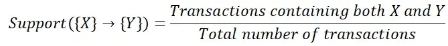

### Confidence
Confidence is a measure of the strength of the association between two items. It is calculated as the number of transactions containing both items divided by the number of transactions containing the first item. High confidence indicates that the presence of the first item is a strong predictor of the presence of the second item.

Confidence Formula
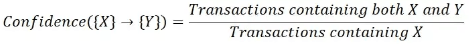

### Lift
Lift is a measure of the strength of the association between two items, taking into account the frequency of both items in the dataset. It is calculated as the confidence of the association divided by the support of the second item. Lift is used to compare the strength of the association between two items to the expected strength of the association if the items were independent. 

A lift value greater than 1 indicates that the association between two items is stronger than expected based on the frequency of the individual items. This suggests that the association may be meaningful and worth further investigation. A lift value less than 1 indicates that the association is weaker than expected and may be less reliable or less significant.

Lift Formula

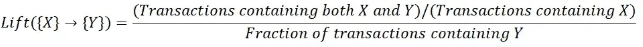



In [22]:
import warnings
warnings.filterwarnings("ignore")

#Import all relevant libraries
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


In [23]:
conditions = [
    (patD['edad'] < 50),
    (patD['edad'] >= 50) & (patD['edad'] < 70),
    (patD['edad'] >= 70),                    # Condition for 'Senior'
    (patD['sexo'] == 'Mujer') & (patD['edad'] < 45)  # Condition for 'Fertil'
]
choices = ['Joven','Medio','Senior', 'Fertil']
patD['edadC'] = np.select(conditions, choices, default='Normal')
conditionsp = [
    (patD['peso'] > 100),     # Condition for 'Senior'
    (patD['peso'] < 50 )      # Condition for 'Fertil'
]
choicesp = ['Alto', 'Bajo']
patD['pesoC'] = np.select(conditionsp, choicesp, default='Normal')

In [24]:
conditionst = [
    (patD['tension_'] < 100),     # Condition for 'Tension baja'
]
choicest = ['Baja']
patD['tensionC'] = np.select(conditionst, choicest, default='Normal')

In [25]:
patD['edadC'].value_counts(dropna=False)

edadC
Senior    57474
Medio     39058
Joven     22917
Name: count, dtype: int64

In [26]:
patD['pesoC'].value_counts(dropna=False)

pesoC
Normal    108181
Alto        8163
Bajo        3105
Name: count, dtype: int64

In [27]:
patD['tensionC'].value_counts(dropna=False)

tensionC
Normal    106901
Baja       12548
Name: count, dtype: int64

In [28]:
patD['raza'] = patD['raza'].fillna('Caucásica')
patD['raza'].value_counts(dropna=False)

raza
Caucásica         115278
América Latina      1695
Arábica             1026
Asiática             712
Negra                265
Romaní               244
Otras                229
Name: count, dtype: int64

In [29]:
patD['fr_cance'] = patD['fr_cance'].fillna('No')
patD['fr_cance'].value_counts(dropna=False)

fr_cance
No    89928
Sí    29521
Name: count, dtype: int64

In [30]:
patD['ana_dura'] = patD['ana_dura'].fillna('No buscada')

In [31]:
patD['ana_dura'].value_counts(dropna=False)

ana_dura
No buscada          96575
Buscada negativo    14306
Buscada positivo     8568
Name: count, dtype: int64

In [32]:
patD['fr_can_l'] = patD['fr_can_l'].cat.add_categories(["No"])

In [33]:
idx = patD['fr_cance']=='Sí'
patD.loc[idx,'fr_can_l'].value_counts(dropna=False)

fr_can_l
Colorrectal                        4327
Pulmón                             4270
Mama                               3600
Próstata                           2619
Hematológico                       2332
Vejiga                             1662
Páncreas                           1428
Útero                              1172
Estómago                           1126
Cerebral (snc)                     1045
Otros                              1036
Ovario                              964
Riñón                               894
Orofaringe/Laringe                  535
Carcinoma de origen desconocido     442
Melanoma                            358
Hepatocarcinoma                     337
Vía biliar                          331
Esófago                             310
Cutáneo                             222
Tiroides                            155
Testículo                           126
Vulva                                95
Pleura                               66
Timo                           

In [34]:
conditionsc = [
    (patD['fr_cance']=='Sí') & (patD['fr_can_e'] == 'Con metástasis'), # Condition for 'w cancer & Metástasis'
    (patD['fr_cance']=='Sí') & (patD['fr_can_e'] == 'Sin metástasis'), # Condition for 'w cancer & w/o Metástasis'
    (patD['fr_cance']=='Sí') & (patD['fr_can_e'] == 'NS/NC'),
    (patD['fr_cance']=='Sí') & (patD['fr_can_e'].isna()),
    (patD['fr_cance']=='No')    
]
choicesc = ['Con metástasis', 'Sin metástasis','No definido','No definido','No']
patD['fr_can_eC'] = np.select(conditionsc, choicesc)

patD.loc[idx,'fr_can_eC'].value_counts(dropna=False)

fr_can_eC
Con metástasis    13146
Sin metástasis    12749
No definido        3626
Name: count, dtype: int64

In [35]:
patD['fr_can_eC'].value_counts(dropna=False)

fr_can_eC
No                89928
Con metástasis    13146
Sin metástasis    12749
No definido        3626
Name: count, dtype: int64

In [36]:
idx2 = patD['fr_cance']=='No'
patD.loc[idx2,'fr_can_l'] = patD.loc[idx2,'fr_can_l'].fillna('No')
patD.loc[idx2,'fr_can_l'].value_counts(dropna=False)

fr_can_l
No                                 89928
Cerebral (snc)                         0
Carcinoma de origen desconocido        0
Cutáneo                                0
Estómago                               0
Esófago                                0
Hematológico                           0
Hepatocarcinoma                        0
Mama                                   0
Melanoma                               0
Colorrectal                            0
Orofaringe/Laringe                     0
Otros                                  0
Pene                                   0
Ovario                                 0
Próstata                               0
Pulmón                                 0
Páncreas                               0
Pleura                                 0
Riñón                                  0
Testículo                              0
Tiroides                               0
Timo                                   0
Vejiga                                 0
Vulva  

In [37]:
patD['fr_cirug'].value_counts(dropna=False)

fr_cirug
No     106691
Sí      12757
NaN         1
Name: count, dtype: int64

In [38]:
patD['fr_cirug'] = patD['fr_cirug'].fillna('No')

In [39]:
patD['fr_inmov'] = patD['fr_inmov'].fillna('No')
patD['fr_inmov'].value_counts(dropna=False)

fr_inmov
No    92185
Sí    27264
Name: count, dtype: int64

In [40]:
patD['fr_inm_m'] = patD['fr_inm_m'].cat.add_categories(["No"])
patD['fr_inm_m'] = patD['fr_inm_m'].fillna('No')
patD['fr_inm_m'].value_counts(dropna=False)

fr_inm_m
No                         92184
Infección aguda             6271
Trauma sin intervención     4919
Otros                       4254
Demencia-depresión          3552
Artropatía                  1884
Déficit motor perm.         1623
Neoplasia                   1565
Broncopatía crónica          839
Ictus agudo                  808
Insuficiencia cardíaca       606
Hemorragia                   288
Cardiopatía isquémica        250
Pancreatitis                 161
Enf. inflam. intestinal      156
Hepatopatía                   89
Name: count, dtype: int64

In [41]:
patD['fr_inm_t'] = patD['fr_inm_t'].cat.add_categories(["No"])
patD['fr_inm_t'] = patD['fr_inm_t'].fillna('No')
patD['fr_inm_t'].value_counts(dropna=False)

fr_inm_t
No                   92803
1 a 4 semanas        11886
Menos de 1 semana     7072
Más de 2 meses        5446
5 a 8 semanas         2242
Name: count, dtype: int64

In [42]:
patD['fr_tvp_a'] = patD['fr_tvp_a'].fillna('No')
patD['fr_tvp_a'].value_counts(dropna=False)

fr_tvp_a
No    103491
Sí     15958
Name: count, dtype: int64

In [43]:
# patD['fr_tvp_a'] = patD['fr_tvp_a'].cat.add_categories(["No"])
patD['fr_tvp_p'] = patD['fr_tvp_p'].fillna('No')
patD['fr_tvp_p'].value_counts(dropna=False)

fr_tvp_p
No        103895
1.0        12808
2.0         2113
3.0          444
4.0          121
5.0           38
6.0           12
7.0            7
8.0            3
10.0           2
9.0            1
2018.0         1
0.0            1
2010.0         1
2017.0         1
53.0           1
Name: count, dtype: int64

In [44]:
patD.loc[patD['fr_tvp_p'] != 'No', 'fr_tvp_p'] = 'Sí'
patD['fr_tvp_p'].value_counts(dropna=False)

fr_tvp_p
No    103895
Sí     15554
Name: count, dtype: int64

In [45]:
patD['fr_antfa'].value_counts(dropna=False)

fr_antfa
NaN    74794
No     41907
Sí      2748
Name: count, dtype: int64

In [46]:
patD['fr_antfa'] = patD['fr_antfa'].fillna('No')
patD['fr_antfa'].value_counts(dropna=False)

fr_antfa
No    116701
Sí      2748
Name: count, dtype: int64

In [47]:
patD['fr_tvs_a'].value_counts(dropna=False)

fr_tvs_a
No     59453
NaN    58014
Sí      1982
Name: count, dtype: int64

In [48]:
patD['fr_tvs_a'] = patD['fr_tvs_a'].fillna('No')
patD['fr_tvs_a'].value_counts(dropna=False)

fr_tvs_a
No    117467
Sí      1982
Name: count, dtype: int64

In [49]:
patD['fr_viaje'] = patD['fr_viaje'].fillna('No')
patD['fr_viaje'].value_counts(dropna=False)

fr_viaje
No    116570
Sí      2879
Name: count, dtype: int64

In [50]:
patD['fr_estro'] = patD['fr_estro'].fillna('No')
patD['fr_estro'].value_counts(dropna=False)

fr_estro
No    112931
Sí      6518
Name: count, dtype: int64

In [51]:
patD['fr_embar'].value_counts(dropna=False)

fr_embar
No    118774
Sí       675
Name: count, dtype: int64

In [52]:
patD['fr_emb_s'] = patD['fr_emb_s'].cat.add_categories(["No"])
patD['fr_emb_s'] = patD['fr_emb_s'].fillna('No')
patD['fr_emb_s'].value_counts(dropna=False)

fr_emb_s
No                   118774
Primer trimestre        285
Tercer trimestre        257
Segundo trimestre       133
Name: count, dtype: int64

In [53]:
patD['fr_varic'] = patD['fr_varic'].fillna('No')
patD['fr_varic'].value_counts(dropna=False)

fr_varic
No    101752
Sí     17697
Name: count, dtype: int64

In [54]:
patD['fr_antec'] = patD['fr_antec'].fillna('No')
patD['fr_antec'].value_counts(dropna=False)

fr_antec
No    118863
Sí       586
Name: count, dtype: int64

In [55]:
patD['sin_tvp_'].value_counts(dropna=False)

sin_tvp_
TVP             52185
EP              43406
TVP/EP          18352
Asintomático     5506
Name: count, dtype: int64

In [56]:
patD['tv_l_vpo'].value_counts(dropna=False)

tv_l_vpo
NaN    79907
No     38426
Sí      1116
Name: count, dtype: int64

In [57]:
patD['tv_l_vme'].value_counts(dropna=False)

tv_l_vme
NaN    80134
No     38645
Sí       670
Name: count, dtype: int64

In [58]:
patD['tv_l_ves'].value_counts(dropna=False)

tv_l_ves
NaN    80239
No     38792
Sí       418
Name: count, dtype: int64

In [59]:
# LOO 5/2/2025
# tv_l_vpo
# tv_l_vme
# tv_l_ves
# estas tres irían agrupadas en una única variable llamada trombosis esplácnica, o como quieras 
#   llamarla para que te cuadre mejor
conditionst = [
    (patD['tv_l_vpo']=='Sí') | (patD['tv_l_vme'] == 'Sí') | (patD['tv_l_ves'] == 'Sí'), 
]
choicest = ['Sí']
patD['trb_splcnc'] = np.select(conditionst, choicest, default='No')
patD['trb_splcnc'].value_counts(dropna=False)

trb_splcnc
No    117881
Sí      1568
Name: count, dtype: int64

In [60]:
patD['tv_l_esu'] = patD['tv_l_esu'].fillna('No')
patD['tv_l_esu'].value_counts(dropna=False)

tv_l_esu
No    113658
Sí      5791
Name: count, dtype: int64

In [61]:
patD['tv_l_svc'] = patD['tv_l_svc'].fillna('No')
patD['tv_l_svc'].value_counts(dropna=False)

tv_l_svc
No    119109
Sí       340
Name: count, dtype: int64

In [62]:
# patD['ana_port'] = patD['ana_port'].fillna('No')
patD['ana_port'].value_counts(dropna=False)

ana_port
No     102569
NaN     16880
Name: count, dtype: int64

In [63]:
patD['evn_reci'] = patD['evn_reci'].fillna('No')
patD['evn_reci'].value_counts(dropna=False)

evn_reci
No    111995
Sí      7454
Name: count, dtype: int64

In [64]:
patD['evn_hemo'] = patD['evn_hemo'].fillna('No')
patD['evn_hemo'].value_counts(dropna=False)

evn_hemo
No    110487
Sí      8962
Name: count, dtype: int64

In [65]:
# LOO 5/2/2025
# tv_l_vre
# tv_l_vrn
# tv_l_vca
# tv_l_yug
# tv_l_ova
# tv_l_sup
# tv_l_pul
# tv_l_pul
# estas en otra variable llamada "otras TUS"
conditionso = [
    (patD['tv_l_vre']=='Sí') | (patD['tv_l_vrn'] == 'Sí') | (patD['tv_l_vca'] == 'Sí') | 
    (patD['tv_l_yug']=='Sí') | (patD['tv_l_ova'] == 'Sí') | (patD['tv_l_sup'] == 'Sí') |
    (patD['tv_l_pul']=='Sí') | (patD['tv_l_pul'] == 'Sí') ]    
choiceso = ['Sí']
patD['othr_TUS'] = np.select(conditionso, choiceso, default='No')
patD['othr_TUS'].value_counts(dropna=False)

othr_TUS
No    116400
Sí      3049
Name: count, dtype: int64

In [66]:
patD.shape

(119449, 174)

In [67]:
# Acuerdate de guardar los datos procesados
file = './trombo_dat0_nonan.pkl'
with  open(file,'wb') as fd:
    pickle.dump(patD,fd)
#

### OJO: Se quitan los ana_dura 'No buscada' (Acuerdo 23/1/2025 con Dres)

In [68]:
# Se quitan los 'ana_dura' == 'No buscada'
patD = patD.loc[patD['ana_dura'] != 'No buscada',:]

In [69]:
patD.shape

(22874, 174)

In [70]:
data = patD[['id_pacie','ana_dura','sexo','edadC','sin_tvp_','trb_splcnc',
             'tv_l_esu','tv_l_svc','othr_TUS','fr_cance',
             'fr_cirug','fr_inmov','fr_tvp_a','fr_estro', # 'ana_port', => Always to No
             'evn_reci','evn_hemo']]
data

,id_pacie,ana_dura,sexo,edadC,sin_tvp_,trb_splcnc,tv_l_esu,tv_l_svc,othr_TUS,fr_cance,fr_cirug,fr_inmov,fr_tvp_a,fr_estro,evn_reci,evn_hemo
0,2,Buscada negativo,Mujer,Senior,TVP,No,No,No,No,No,No,No,Sí,No,No,No
6,8,Buscada negativo,Hombre,Senior,TVP,No,No,No,No,Sí,No,Sí,Sí,No,No,No
7,9,Buscada negativo,Mujer,Senior,TVP,No,No,No,No,No,No,Sí,No,No,No,No
10,12,Buscada negativo,Hombre,Senior,TVP/EP,No,No,No,No,No,No,No,No,No,Sí,No
34,36,Buscada negativo,Hombre,Medio,EP,No,No,No,No,No,No,No,Sí,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119381,152926,Buscada positivo,Hombre,Medio,EP,No,No,No,No,No,No,No,No,No,No,No
119393,152956,Buscada negativo,Mujer,Joven,TVP,No,No,No,Sí,No,No,No,No,Sí,No,Sí
119394,152957,Buscada negativo,Mujer,Joven,TVP,No,No,Sí,No,No,No,No,No,No,No,No
119399,152970,Buscada positivo,Hombre,Joven,TVP,No,No,No,No,No,No,No,No,No,No,No


In [71]:
data.shape

(22874, 16)

In [72]:
data.isna().sum()

id_pacie      0
ana_dura      0
sexo          0
edadC         0
sin_tvp_      0
trb_splcnc    0
tv_l_esu      0
tv_l_svc      0
othr_TUS      0
fr_cance      0
fr_cirug      0
fr_inmov      0
fr_tvp_a      0
fr_estro      0
evn_reci      0
evn_hemo      0
dtype: int64

In [73]:
# Building the list of lists
ldata = [
    # [f"{col}:{value}" for col, value in row.items() if (col in {'fr_cance', 'fr_inmov', \
    #                                     'fr_estro','fr_cirug'} or value != "No") and col != "id_pacie"
    # ]     for _, row in data.iterrows()
    [f"{col}:{value}" for col, value in row.items() if (value != "No") and col != "id_pacie"
    ]     for _, row in data.iterrows()
]

In [74]:
[len(ldata[j]) for j in range(100)]

[5,
 7,
 5,
 5,
 5,
 6,
 4,
 4,
 6,
 4,
 5,
 5,
 5,
 5,
 6,
 5,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 4,
 4,
 5,
 5,
 4,
 5,
 4,
 4,
 5,
 5,
 4,
 6,
 5,
 4,
 6,
 5,
 5,
 5,
 5,
 5,
 5,
 4,
 4,
 5,
 6,
 5,
 5,
 5,
 4,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 4,
 4,
 5,
 6,
 5,
 7,
 4,
 5,
 5,
 5,
 4,
 6,
 4,
 4,
 4,
 4,
 6,
 5,
 5,
 4,
 4,
 5,
 5,
 5,
 4,
 4,
 6,
 6,
 4,
 4,
 5,
 5,
 5,
 4,
 5,
 4,
 4,
 6,
 5,
 5,
 5]

In [75]:
ldata[0]

['ana_dura:Buscada negativo',
 'sexo:Mujer',
 'edadC:Senior',
 'sin_tvp_:TVP',
 'fr_tvp_a:Sí']

In [76]:
# lc = data.columns.tolist()
# for ic in lc:
#     print(f"Column {ic}")
#     print(data[ic].value_counts())

In [77]:
# Acuerdate de guardar los datos procesados
file = './trombo_dat2.pkl'
with  open(file,'wb') as fd:
    pickle.dump(patD,fd)
    pickle.dump(ldata,fd)
    pickle.dump(data,fd)
#

In [78]:
patD.loc[patD['ana_dura']=='Buscada positivo','sexo'].value_counts()

sexo
Hombre    4746
Mujer     3822
Name: count, dtype: int64

In [79]:
patD.loc[patD['fr_antfa']=='Sí','ana_dura'].value_counts()

ana_dura
Buscada negativo    526
Buscada positivo    383
No buscada            0
Name: count, dtype: int64

In [80]:
from sklearn.metrics import mutual_info_score
import pandas as pd

def mutual_information_matrix(df):
    categorical_columns = df.select_dtypes(include=['object', 'category']).columns
    mi_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

    for col1 in categorical_columns:
        for col2 in categorical_columns:
            if col1 == col2:
                mi_matrix.loc[col1, col2] = 1.0
            else:
                mi_matrix.loc[col1, col2] = mutual_info_score(df[col1], df[col2])

    return mi_matrix.astype(float)

In [81]:
#mi_matrix = mutual_information_matrix(datanocausa)

In [82]:
categorical_columns = data.select_dtypes(include=['object', 'category']).columns

In [83]:
categorical_columns

Index(['ana_dura', 'sexo', 'edadC', 'sin_tvp_', 'trb_splcnc', 'tv_l_esu',
       'tv_l_svc', 'othr_TUS', 'fr_cance', 'fr_cirug', 'fr_inmov', 'fr_tvp_a',
       'fr_estro', 'evn_reci', 'evn_hemo'],
      dtype='object')

In [84]:
mutual_info_score(data['ana_dura'], data['fr_estro'])

1.1881345159975298e-05

In [85]:
mi_matrix = mutual_information_matrix(data)

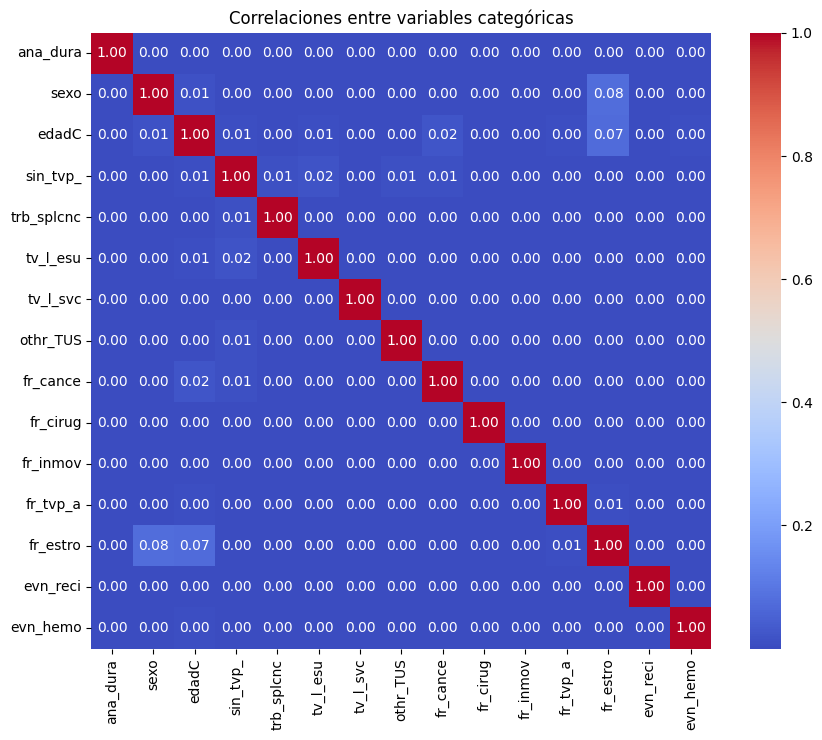

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cambia cramer_matrix o mi_matrix según el método utilizado
plt.figure(figsize=(10, 8))
sns.heatmap(mi_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlaciones entre variables categóricas")
plt.show()

In [87]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    return np.sqrt(phi2 / min(r-1, k-1))

def cramers_v_matrix(df):
    categorical_columns = df.select_dtypes(include=['object', 'category']).columns
    cramer_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

    for col1 in categorical_columns:
        for col2 in categorical_columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

    return cramer_matrix.astype(float)

In [88]:
cramer_matrix = cramers_v_matrix(data)
print(cramer_matrix)

            ana_dura      sexo     edadC  sin_tvp_  trb_splcnc  tv_l_esu  \
ana_dura    1.000000  0.039044  0.060110  0.054319    0.014085  0.032050   
sexo        0.039044  1.000000  0.166599  0.046682    0.032930  0.017065   
edadC       0.060110  0.166599  1.000000  0.072609    0.023397  0.107352   
sin_tvp_    0.054319  0.046682  0.072609  1.000000    0.211400  0.176238   
trb_splcnc  0.014085  0.032930  0.023397  0.211400    1.000000  0.021720   
tv_l_esu    0.032050  0.017065  0.107352  0.176238    0.021720  1.000000   
tv_l_svc    0.005991  0.031434  0.056883  0.067711    0.008753  0.006885   
othr_TUS    0.044300  0.015182  0.014737  0.151976    0.019478  0.026236   
fr_cance    0.032903  0.011017  0.194254  0.181042    0.033214  0.049097   
fr_cirug    0.021382  0.027756  0.047518  0.051335    0.009650  0.011490   
fr_inmov    0.035874  0.006927  0.047159  0.040278    0.015633  0.051076   
fr_tvp_a    0.007545  0.031555  0.091362  0.047615    0.018113  0.029967   
fr_estro    

**Interpretación:**

**0.0**: Sin asociación.

**0.0–0.3**: Asociación débil.

**0.3–0.6**: Asociación moderada.

**0.6–1.0**: Asociación fuerte.


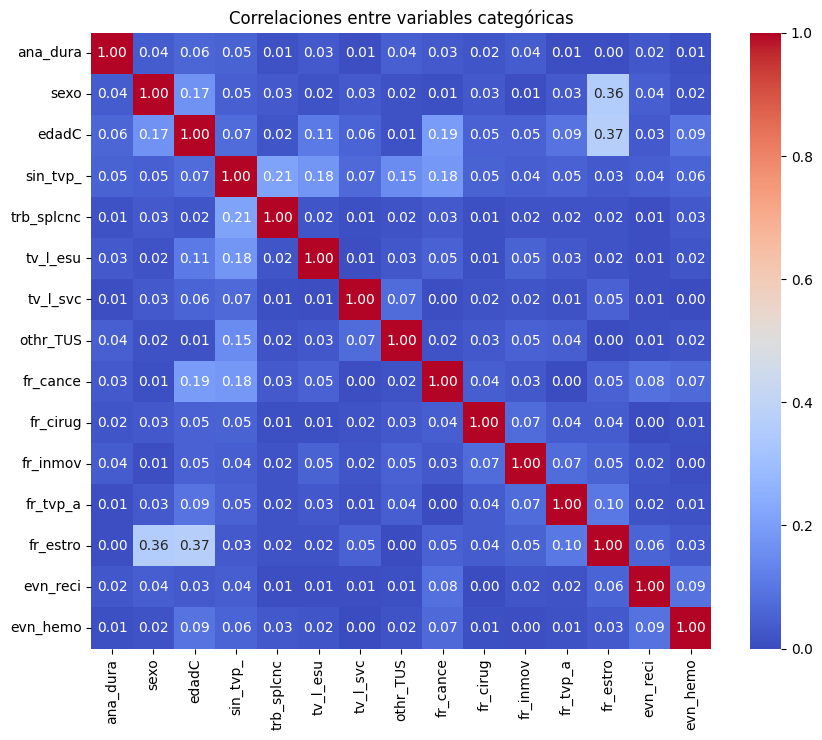

In [89]:
plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlaciones entre variables categóricas")
plt.show()